# P3: Tahap 2 - Baseline & ARF Streaming Evaluation

Di notebook ini, kita akan melakukan evaluasi model *online learning* menggunakan metode **Prequential Evaluation (Interleaved Test-Then-Train)**. Model akan memprediksi data yang masuk terlebih dahulu sebelum belajar dari data tersebut.

In [4]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import scipy.integrate

# [FIX] Kompatibilitas untuk Scipy versi terbaru (>1.14) yang menghapus 'trapz'
if not hasattr(scipy.integrate, 'trapz'):
    scipy.integrate.trapz = scipy.integrate.trapezoid

# Tambahkan src/ ke sys.path
sys.path.append(os.path.abspath('../src'))
from stream_utils import iter_csv
from pipeline import get_baseline_model, get_arf_model

from river import metrics
from river import evaluate

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Setup Metrik & Batasan
Karena Credit Card Fraud berjumlah 284.807 baris, kita bisa melakukan simulasi stream penuh atau dibatasi untuk eksperimen awal.

In [5]:
DATA_PATH = '../data/raw/creditcard.csv'
TARGET_COL = 'Class'
LIMIT = 50000  # Ubah ke None untuk memproses semua data

def evaluate_model_custom(model, model_name):
    metric_auc = metrics.ROCAUC()
    metric_gmean = metrics.GeometricMean()
    
    stream = iter_csv(DATA_PATH, target_col=TARGET_COL, limit=LIMIT)
    
    steps = []
    auc_scores = []
    
    print(f"Memulai evaluasi untuk {model_name}...")
    for i, (x, y) in enumerate(stream):
        # 1. Test: Prediksi data yang belum dilihat
        y_pred = model.predict_proba_one(x)
        
        # Karena prediksi mengembalikan dictionary class probabilities {0: p0, 1: p1}
        # Kita ambil probabilitas kelas 1 (Fraud)
        p_fraud = y_pred.get(1, 0.0) if y_pred else 0.0
        y_pred_class = model.predict_one(x)
        
        # Update metrik
        metric_auc.update(y, p_fraud)
        if y_pred_class is not None:
            metric_gmean.update(y, y_pred_class)
            
        # 2. Train: Update model dengan data asli
        model.learn_one(x, y)
        
        # Simpan metrik setiap 5000 transaksi untuk di-plot
        if (i + 1) % 5000 == 0:
            steps.append(i + 1)
            auc_scores.append(metric_auc.get())
            print(f"[{model_name}] Step {i+1} | AUC: {metric_auc.get():.4f} | G-Mean: {metric_gmean.get():.4f}")
            
    return steps, auc_scores

## 2. Eksekusi Prequential Evaluation
Menjalankan model Baseline (Hoeffding Tree) dan Proposed (Adaptive Random Forest).

In [6]:
# Load Model
ht_model = get_baseline_model()
arf_model = get_arf_model()

# Evaluasi
ht_steps, ht_auc = evaluate_model_custom(ht_model, "Hoeffding Tree (Baseline)")
print("-" * 40)
arf_steps, arf_auc = evaluate_model_custom(arf_model, "Adaptive Random Forest")

Memulai evaluasi untuk Hoeffding Tree (Baseline)...
[Hoeffding Tree (Baseline)] Step 5000 | AUC: 0.5000 | G-Mean: 0.0000
[Hoeffding Tree (Baseline)] Step 10000 | AUC: 0.5000 | G-Mean: 0.0000
[Hoeffding Tree (Baseline)] Step 15000 | AUC: 0.5000 | G-Mean: 0.0000
[Hoeffding Tree (Baseline)] Step 20000 | AUC: 0.5000 | G-Mean: 0.0000
[Hoeffding Tree (Baseline)] Step 25000 | AUC: 0.5000 | G-Mean: 0.0000
[Hoeffding Tree (Baseline)] Step 30000 | AUC: 0.5000 | G-Mean: 0.0000
[Hoeffding Tree (Baseline)] Step 35000 | AUC: 0.5000 | G-Mean: 0.0000
[Hoeffding Tree (Baseline)] Step 40000 | AUC: 0.5000 | G-Mean: 0.0000
[Hoeffding Tree (Baseline)] Step 45000 | AUC: 0.5000 | G-Mean: 0.0000
[Hoeffding Tree (Baseline)] Step 50000 | AUC: 0.5000 | G-Mean: 0.0000
----------------------------------------
Memulai evaluasi untuk Adaptive Random Forest...
[Adaptive Random Forest] Step 5000 | AUC: 0.5000 | G-Mean: 0.0000
[Adaptive Random Forest] Step 10000 | AUC: 0.5000 | G-Mean: 0.0000
[Adaptive Random Forest] S

## 3. Visualisasi Perbandingan Kinerja
Melihat pergerakan ROC AUC seiring berjalannya waktu.

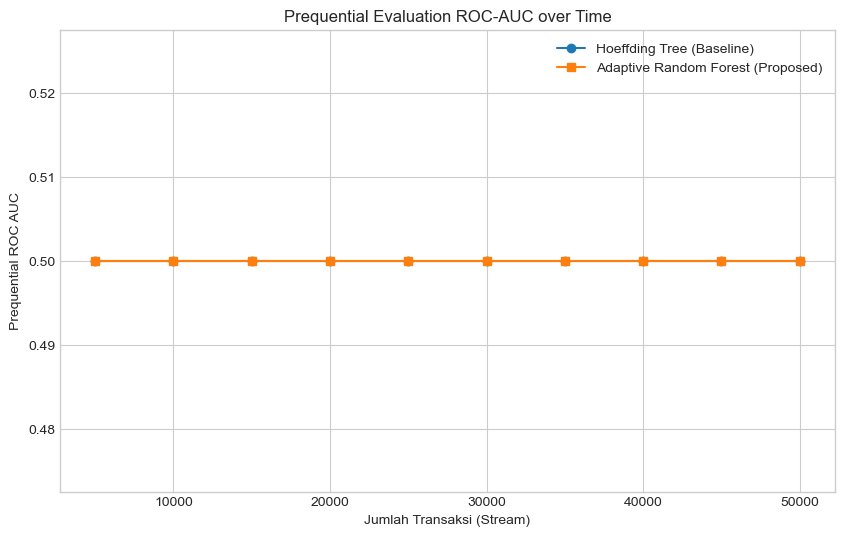

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(ht_steps, ht_auc, label='Hoeffding Tree (Baseline)', marker='o')
plt.plot(arf_steps, arf_auc, label='Adaptive Random Forest (Proposed)', marker='s')
plt.title('Prequential Evaluation ROC-AUC over Time')
plt.xlabel('Jumlah Transaksi (Stream)')
plt.ylabel('Prequential ROC AUC')
plt.legend()
plt.show()